In [1]:
from typing import TYPE_CHECKING

import qualtran as qlt
import qualtran.dtype as qdt

from qualtran.l3 import bloqify

if TYPE_CHECKING:
    from qualtran import BloqBuilder, QVar, QVarT

# Quantum Control Flow

For any program to be useful, it must give answers for a variety of inputs. This typically involves changing the path of execution of a program through branches, conditionals, loops, and more in a general concept known as *control flow*. 

Quantum mechanics severely limits the types of control flow we can do coherently. A purely quantum program is a deterministic, sequential execution of quantum operations. Quantum branching of a quantum program counter would run into Maxwell's demon style problems. For practical quantum computers, the program counter is handled by a classical CPU and we have two general types of control flow.

In the first type of control flow, we can use *measurement* of a quantum state to provide incoherent classical bits to branch on. This is the bedrock of quantum error correction protocols and shows up in compilations of subroutines like gate teleportation and ancilla-assisted rotation synthesis.

In the second type of control flow, which we investigate in this document, is a bit more nebulous. Instead of considering a quantum program consisting of concrete gates and subroutines; we consider a template quantum program consisting of gate families and classically parameterized subroutines. The gate families are parameterized to allow easy substitution of e.g. different input specifications for problems; meaning that the subroutines give the simulacrum of quantum control flow. 

In this document, we investigate some of the ways of building up (simulated) quantum control flow using a gateset that provides single-bit-controlled 'versions' of our familiar quantum gates.

## A parameterized subroutine `XorK`

In [2]:
@bloqify
def xor_k(bb: 'BloqBuilder', x: 'QVar', k: int):    
    xs = x[:]
    for i, bit in enumerate(x.dtype.to_bits(k)):
        if bit == 1:
            xs[i] = ~xs[i]

    return {'x': bb.join(xs, dtype=x.dtype)}

In [3]:
import attrs
XorK = xor_k.make_bloq_class(qlt.Signature.build(x=qdt.QUInt(8)), k=attrs.field(type=int))

### Instantiate a circuit for different choices of `k`

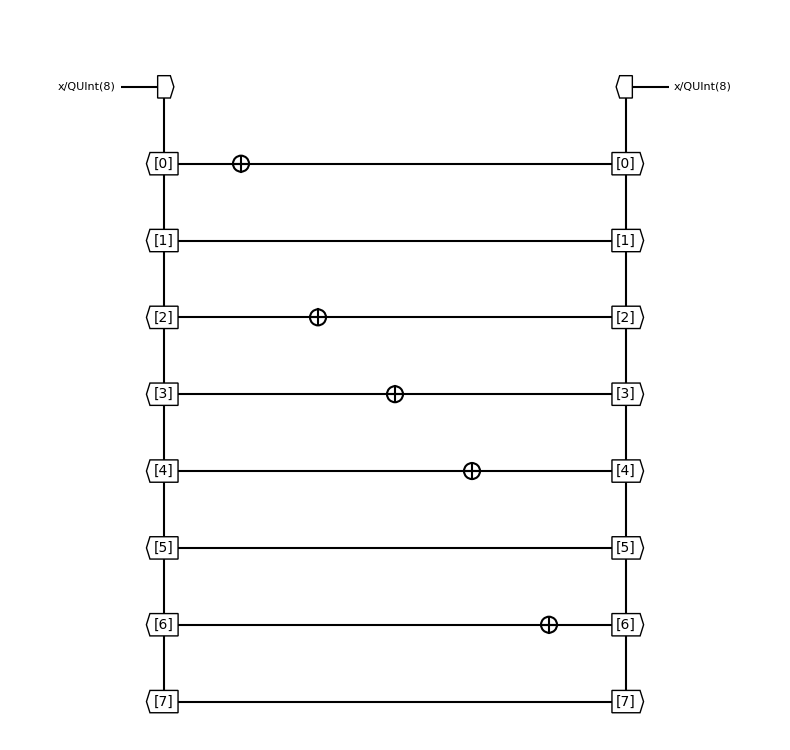

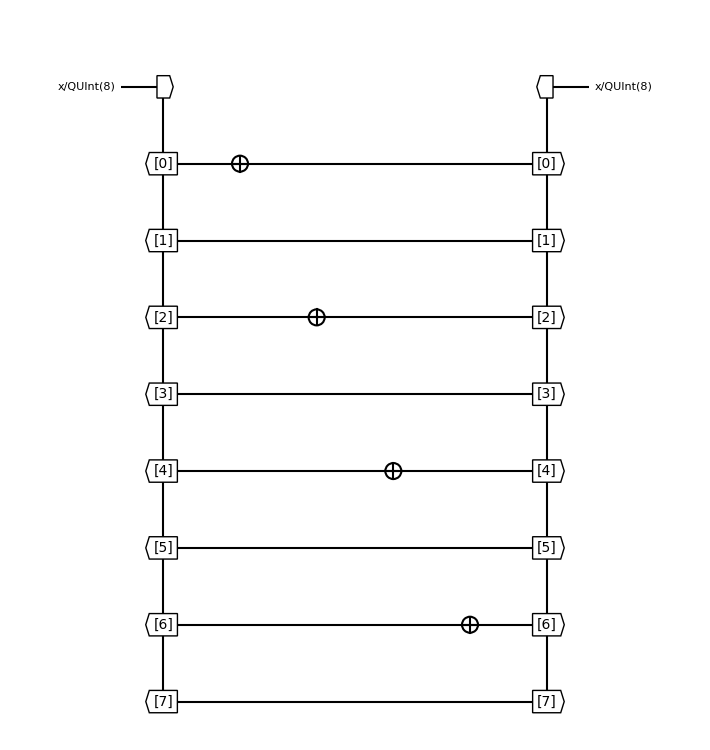

In [4]:
def get_xor_k(k):
    return xor_k.make(qlt.Signature.build(x=qdt.QUInt(8)), k=k)

xor186 = get_xor_k(186)
qlt.show_bloq(xor186, 'musical_score')

xor170 = get_xor_k(170)
qlt.show_bloq(xor170, 'musical_score')

## A choice

What if --- based on the result of another part of the computation --- we want to load either 186 or 170 into a fresh register. We'll need to build up some logic.

For these specific parameter choices, you can see that bit index 3 is the only one that differs. But we're still considering these gate families and will construct general versions of this control flow. Further design automation could identify these savings. 

In [5]:
@bloqify
def cxor_k(bb: 'BloqBuilder', ctrl:'QVar',  x: 'QVar', k: int):
    assert ctrl.dtype == qdt.QBit(), ctrl
    
    xs = x[:]
    for i, bit in enumerate(qdt.QUInt(x.dtype.num_bits).to_bits(k)):
        if bit == 1:
            ctrl, xs[i] = bb.CNOT(ctrl, xs[i])

    return {'x': bb.join(xs, dtype=x.dtype), 'ctrl': ctrl}

def get_cxor_k(k, bitsize=8):
    return cxor_k.make(qlt.Signature.build(ctrl=1, x=bitsize), k=k)

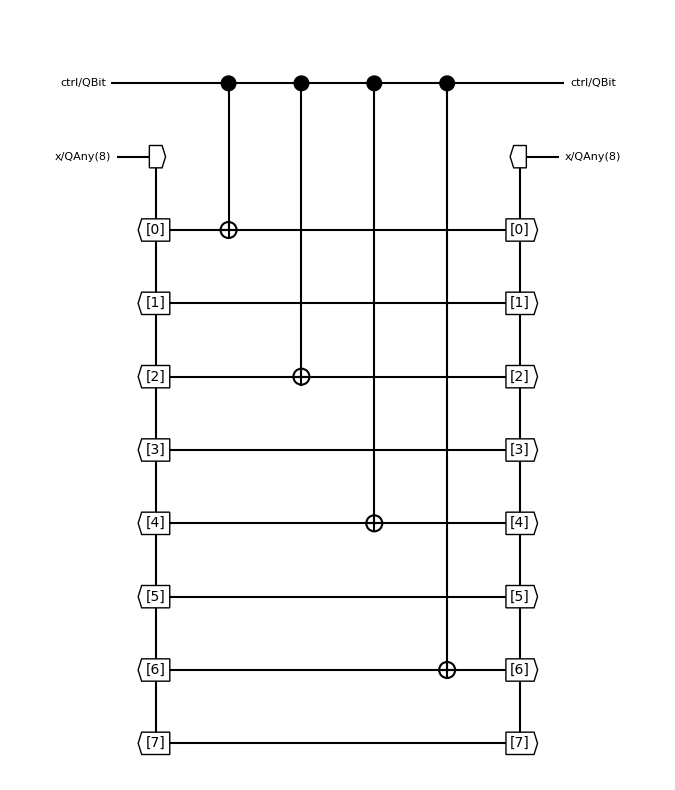

In [6]:
cxor170 = get_cxor_k(170)
qlt.show_bloq(cxor170, 'musical_score')

## A choice

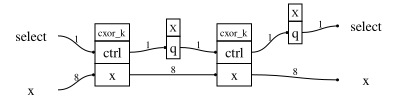

In [7]:
@bloqify
def select1(bb: 'BloqBuilder', select: 'QVar', x: 'QVar', k1: int, k2: int):
    select, x     = cxor_k(bb, ctrl=select, x=x, k=k1)
    inv_select    = ~select
    inv_select, x = cxor_k(bb, ctrl=inv_select, x=x, k=k2)
    select        = ~inv_select
    return {
        'select': select,
        'x': x,
    }
    
prog = select1.make(qlt.Signature.build(select=1, x=qdt.QUInt(8)), k1=170, k2=186)
qlt.show_bloq(prog)

### Display niceness

In [8]:
from qualtran.bloqs.arithmetic import XorK
def cxor_k(bb, ctrl, x, k):
    return bb.add(XorK(x.dtype, k=k).controlled(), ctrl=ctrl, x=x)

def get_cxor_k(k, dtype=qdt.QUInt(8)):
    return XorK(dtype, k=k).controlled()

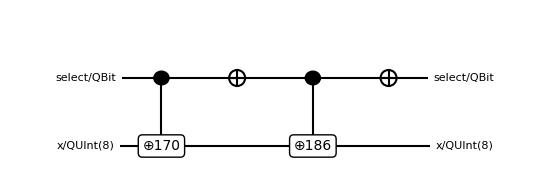

In [9]:
@bloqify
def select1(bb: 'BloqBuilder', select: 'QVar', x: 'QVar', k1: int, k2: int):
    select, x     = cxor_k(bb, ctrl=select, x=x, k=k1)
    inv_select    = ~select
    inv_select, x = cxor_k(bb, ctrl=inv_select, x=x, k=k2)
    select        = ~inv_select
    return {
        'select': select,
        'x': x,
    }
prog = select1.make(qlt.Signature.build(select=1, x=qdt.QUInt(8)), k1=170, k2=186)
qlt.show_bloq(prog, 'musical_score')

In [10]:
@bloqify
def cselect1(bb, ctrl: 'QVar', select: 'QVar', b0, b1, system: 'QVarT'):
    assert ctrl.dtype == qdt.QBit(), ctrl
    assert select.dtype == qdt.QBit(), select

    [ctrl, select], active = bb.And([ctrl,select], cv1=1, cv2=0)
    active, system         = bb.add(b0, ctrl=active, x=system)
    ctrl, active           = bb.CNOT(ctrl, active)
    active, system         = bb.add(b1, ctrl=active, x=system)
    [ctrl, select]         = bb.UnAnd([ctrl,select], active, cv1=1, cv2=1)

    return {'ctrl': ctrl, 'select': select, 'system': system}

In [11]:
load100 = get_cxor_k(k=100)
(
    load100.call_classically(ctrl=0, x=0),
    load100.call_classically(ctrl=1, x=0),
)

((0, 0), (1, 100))

In [12]:
load101 = get_cxor_k(k=101)
(
    load101.call_classically(ctrl=0, x=0),
    load101.call_classically(ctrl=1, x=0),
)

((0, 0), (1, 101))

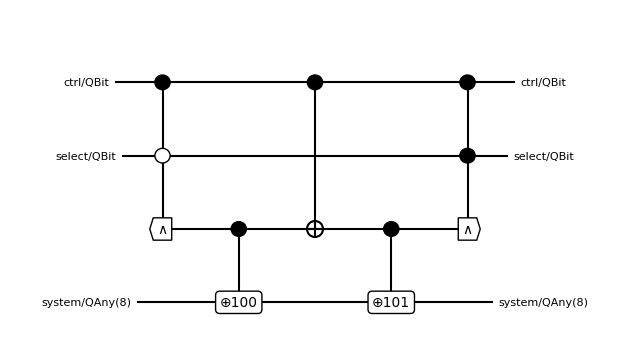

In [13]:
cs1 = cselect1.make(qlt.Signature.build(ctrl=1, select=1, system=8), b0=load100, b1=load101)

from qualtran.drawing.musical_score import _MusicalScoreLayoutBuilder, draw_musical_score
lb = _MusicalScoreLayoutBuilder.from_cbloq(cs1)
lb.do_horizontal_layout()
#lb.draw_hline_labels(cs1)
lines = ['ctrl', 'select', 'target', 'system']
msd = lb.finalize_aboslute_layout(lines)
fig, ax = draw_musical_score(msd)
fig.savefig('cselect1.pdf')

#qlt.show_bloq(cs1, 'musical_score')

In [14]:
(
    cs1.call_classically(ctrl=0, system=0, select=0),
    cs1.call_classically(ctrl=0, system=0, select=1)
)

((0, 0, 0), (0, 1, 0))

In [15]:
(
    cs1.call_classically(ctrl=1, system=0, select=0),
    cs1.call_classically(ctrl=1, system=0, select=1)
)

((1, 0, 100), (1, 1, 101))

## Recursive: use cselect(n-1) as what we're selecting between

In [16]:
import numpy as np
OPS = np.array([get_cxor_k(k=100+i) for i in range(2**3)]).reshape((2,)*3)

In [17]:
@bloqify
def cselect(bb, ctrl: 'QVar', selects: 'QVarT', system: 'QVarT', address=()):
    select = selects[0]
    subselects = selects[1:]
    assert ctrl.dtype == qdt.QBit(), ctrl
    assert select.dtype == qdt.QBit(), select

    [ctrl, select], active = bb.And([ctrl, select], cv1=1, cv2=0)

    if len(subselects) > 0:
        active, subselects, system = cselect(
            bb,
            ctrl=active, selects=subselects, system=system,
            address=address + (0,)
        )
    else:
        # base case address + (0,)
        op = OPS[address+(0,)]
        active, system = bb.add(op, ctrl=active, x=system)

    # Flip `active`
    ctrl, active = bb.CNOT(ctrl, active)

    if len(subselects) > 0:
        active, subselects, system = cselect(
            bb,
            ctrl=active, selects=subselects, system=system,
            address=address + (1,)
        )
    else:
        # base case address + (1,)
        op = OPS[address+(1,)]
        active, system = bb.add(op, ctrl=active, x=system)

    [ctrl, select] = bb.UnAnd([ctrl, select], active, cv1=1, cv2=1)

    selects = [select] + subselects.tolist()
    return {'ctrl': ctrl, 'selects': selects, 'system': system}

In [18]:
cs = cselect.make(qlt.Signature.build(ctrl=1, selects=qdt.QBit()[3], system=8))

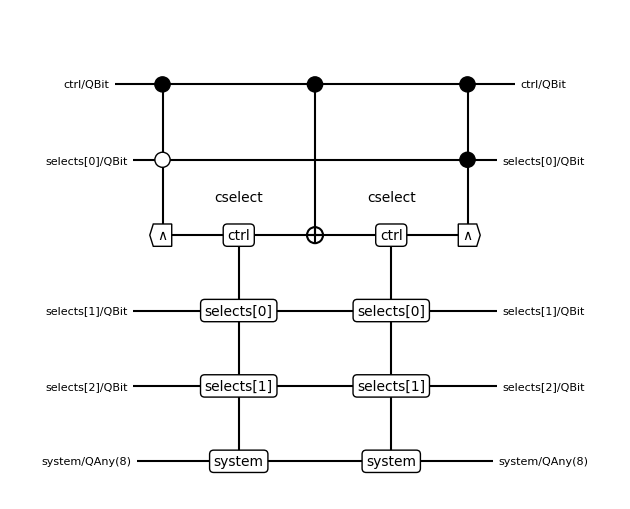

In [19]:
from qualtran.drawing.musical_score import _MusicalScoreLayoutBuilder, draw_musical_score
lb = _MusicalScoreLayoutBuilder.from_cbloq(cs)
lb.do_horizontal_layout()
#lb.draw_hline_labels(cs)
lines = ['ctrl', 'selects', 'target', 'selects1', 'selects2',  'system']
msd = lb.finalize_aboslute_layout(lines)
fig, ax = draw_musical_score(msd)
fig.savefig('cselect.pdf')

#qlt.show_bloq(cs, 'musical_score')

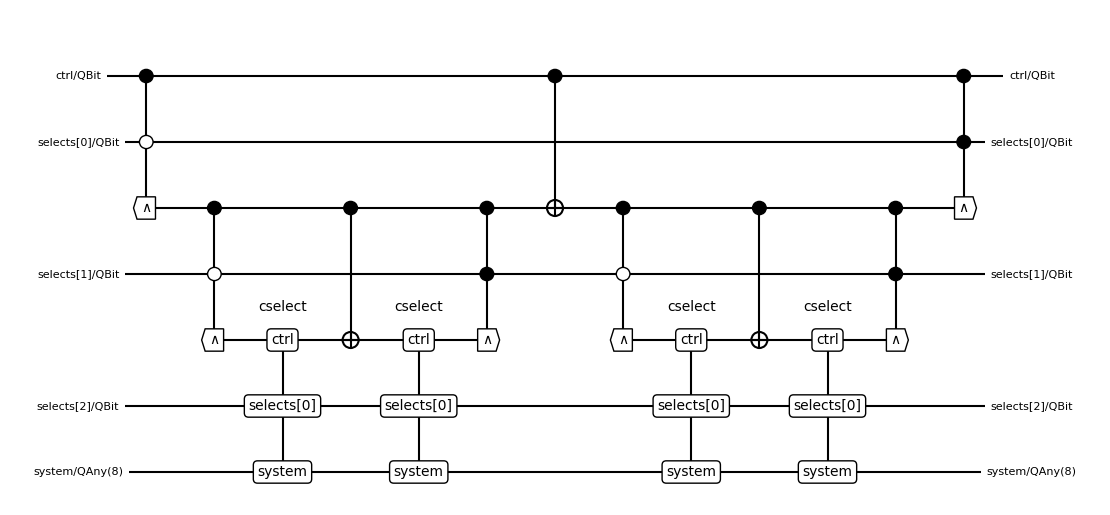

In [25]:
cs_f1 = cs.flatten_once()

lb = _MusicalScoreLayoutBuilder.from_cbloq(cs_f1)
lb.do_horizontal_layout()
lb.draw_hline_labels(cs_f1)
lines = ['ctrl', 'selects', 'target', 'selects1', ('target1', 'target2'), 'selects2',  'system']
msd = lb.finalize_aboslute_layout(lines)

fig, ax = draw_musical_score(msd, max_width=100, max_height=100, unit_to_inches=0.7)
fig.savefig('cs_f1.pdf')

#qlt.show_bloq(cs.flatten_once(), 'musical_score')

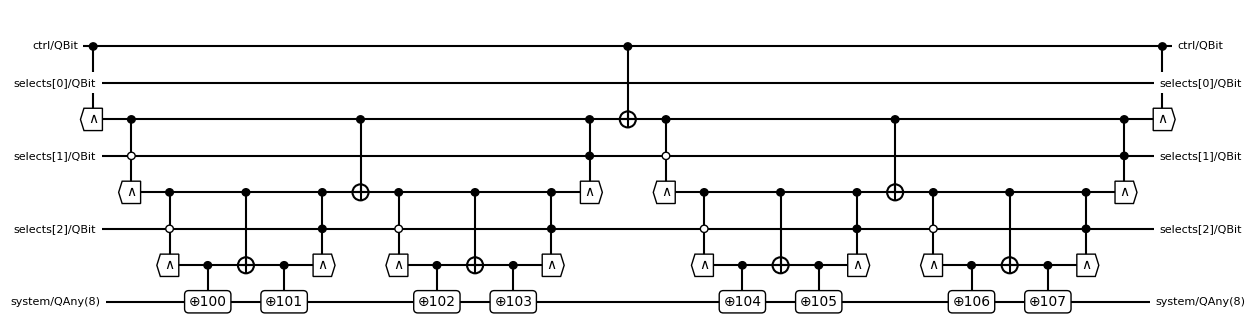

In [22]:
cs_f2 = cs.flatten_once().flatten_once()

lb = _MusicalScoreLayoutBuilder.from_cbloq(cs_f2)
lb.do_horizontal_layout()
lb.draw_hline_labels(cs_f2)
lines = [
    'ctrl', 
    'selects', 
    ('target',), 
    'selects1', 
    ('target1', 'target4'), 
    'selects2', 
    ('target2', 'target3', 'target5', 'target6'),
    'system'
]
msd = lb.finalize_aboslute_layout(lines)
fig, ax = draw_musical_score(msd, max_width=100, max_height=100, unit_to_inches=0.4)
fig.savefig('cs_f2.pdf')
#qlt.show_bloq(cs.flatten_once().flatten_once(), 'musical_score')

In [23]:
cs = cselect.make(qlt.Signature.build(
    ctrl=1, selects=qdt.QBit()[3], system=8))

for i in range(8):
    addr = [int(b) for b in f'{i:03b}']
    ctrl_out, selects_out, sys_out = cs.call_classically(ctrl=1, selects=addr, system=0)
    print(f'{i:<3d} {addr!s:10} {sys_out}')

0   [0, 0, 0]  100
1   [0, 0, 1]  101
2   [0, 1, 0]  102
3   [0, 1, 1]  103
4   [1, 0, 0]  104
5   [1, 0, 1]  105
6   [1, 1, 0]  106
7   [1, 1, 1]  107
